# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Geting The Unemployment Dataset

In [2]:
url = "https://api.worldbank.org/v2/country/WLD/indicator/SL.UEM.TOTL.ZS?format=json&per_page=100"

response = requests.get(url)

data = response.json()[1]

df = pd.DataFrame(data)

df.head()

,indicator,country,countryiso3code,date,value,unit,obs_status,decimal
0,"{'id': 'SL.UEM.TOTL.ZS', 'value': 'Unemploymen...","{'id': '1W', 'value': 'World'}",WLD,2025,4.791333,,,1
1,"{'id': 'SL.UEM.TOTL.ZS', 'value': 'Unemploymen...","{'id': '1W', 'value': 'World'}",WLD,2024,4.806280,,,1
2,"{'id': 'SL.UEM.TOTL.ZS', 'value': 'Unemploymen...","{'id': '1W', 'value': 'World'}",WLD,2023,4.849917,,,1
3,"{'id': 'SL.UEM.TOTL.ZS', 'value': 'Unemploymen...","{'id': '1W', 'value': 'World'}",WLD,2022,5.234628,,,1
4,"{'id': 'SL.UEM.TOTL.ZS', 'value': 'Unemploymen...","{'id': '1W', 'value': 'World'}",WLD,2021,6.045561,,,1


Select Important columns

In [3]:
df = df[["date", "value"]]

df.columns = ["Year", "Unemployment_Rate"]

df.head()

,Year,Unemployment_Rate
0,2025,4.791333
1,2024,4.806280
2,2023,4.849917
3,2022,5.234628
4,2021,6.045561


# Cleaning The Data

In [4]:
df["Year"] = pd.to_numeric(df["Year"])

df["Unemployment_Rate"] = pd.to_numeric(
    df["Unemployment_Rate"],
    errors="coerce"
)

df = df.dropna()

df = df.sort_values("Year")

df = df.reset_index(drop=True)

df.head()

,Year,Unemployment_Rate
0,1991,5.119441
1,1992,5.275535
2,1993,5.543660
3,1994,5.789283
4,1995,5.919523


# Dataset Check

In [5]:
print("Number of rows:", len(df))

print("\nFirst 10 rows:")
print(df.head(10))

print("\nLast 10 rows:")
print(df.tail(10))

Number of rows: 35

First 10 rows:
   Year  Unemployment_Rate
0  1991           5.119441
1  1992           5.275535
2  1993           5.543660
3  1994           5.789283
4  1995           5.919523
5  1996           5.983796
6  1997           6.010235
7  1998           6.159184
8  1999           6.278476
9  2000           6.111370

Last 10 rows:
    Year  Unemployment_Rate
25  2016           5.970883
26  2017           5.898024
27  2018           5.759542
28  2019           5.588480
29  2020           6.587689
30  2021           6.045561
31  2022           5.234628
32  2023           4.849917
33  2024           4.806280
34  2025           4.791333


# Basic Statistics


In [6]:
df["Unemployment_Rate"].describe()

,Unemployment_Rate
count,35.000000
mean,5.885219
std,0.472141
min,4.791333
25%,5.767227
50%,5.983796
75%,6.174550
max,6.587689


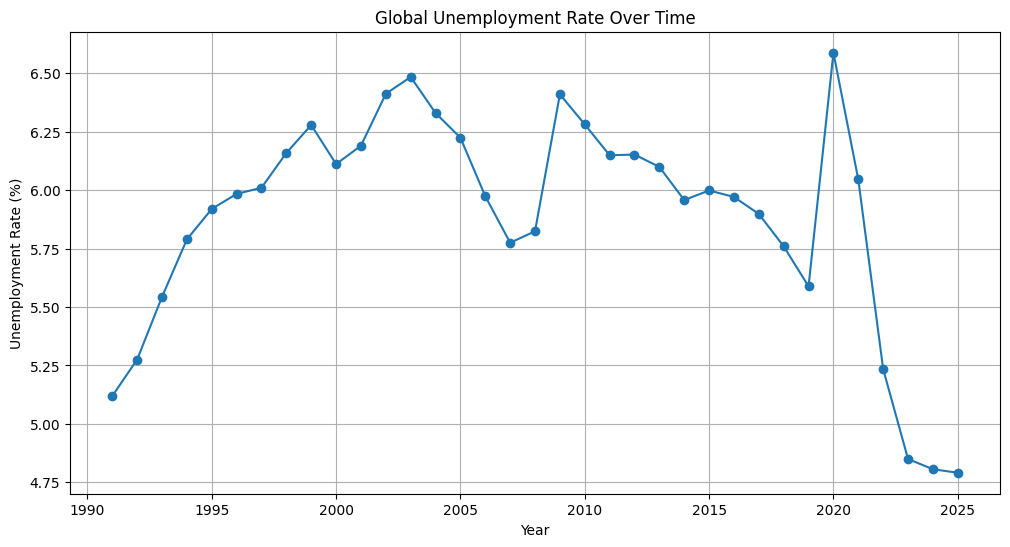

In [7]:
plt.figure(figsize=(12, 6))

plt.plot(
    df["Year"],
    df["Unemployment_Rate"],
    marker="o"
)

plt.title("Global Unemployment Rate Over Time")
plt.xlabel("Year")
plt.ylabel("Unemployment Rate (%)")

plt.grid(True)

plt.show()

look specifically at Covid

In [9]:
covid_period = df[
    (df["Year"] >= 2018) &
    (df["Year"] <= 2022)
]

print(covid_period)

    Year  Unemployment_Rate
27  2018           5.759542
28  2019           5.588480
29  2020           6.587689
30  2021           6.045561
31  2022           5.234628


Graphical **Representation**

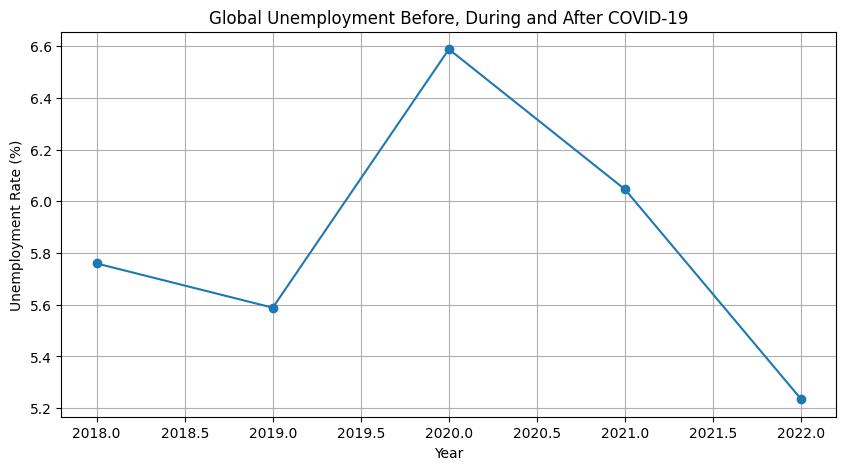

In [10]:
plt.figure(figsize=(10, 5))

plt.plot(
    covid_period["Year"],
    covid_period["Unemployment_Rate"],
    marker="o"
)

plt.title("Global Unemployment Before, During and After COVID-19")
plt.xlabel("Year")
plt.ylabel("Unemployment Rate (%)")

plt.grid(True)

plt.show()


## **Compare the latest 5 years**

In [11]:
last_5_years = df[
    (df["Year"] >= 2021) &
    (df["Year"] <= 2025)
]

print(last_5_years)

    Year  Unemployment_Rate
30  2021           6.045561
31  2022           5.234628
32  2023           4.849917
33  2024           4.806280
34  2025           4.791333


**Graph**

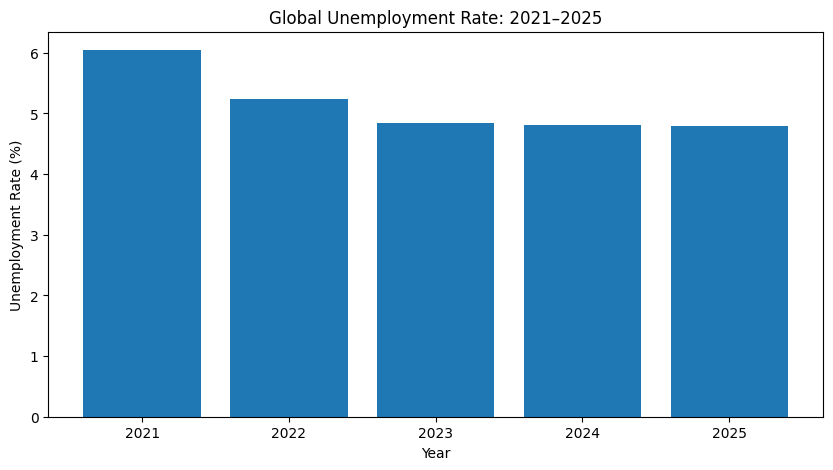

In [12]:
plt.figure(figsize=(10, 5))

plt.bar(
    last_5_years["Year"].astype(str),
    last_5_years["Unemployment_Rate"]
)

plt.title("Global Unemployment Rate: 2021–2025")
plt.xlabel("Year")
plt.ylabel("Unemployment Rate (%)")

plt.show()

# Calculate The Change

In [13]:
rate_2021 = last_5_years[
    last_5_years["Year"] == 2021
]["Unemployment_Rate"].iloc[0]

rate_2025 = last_5_years[
    last_5_years["Year"] == 2025
]["Unemployment_Rate"].iloc[0]

change = rate_2025 - rate_2021

print("2021 unemployment rate:", rate_2021)
print("2025 unemployment rate:", rate_2025)
print("Change:", change)

2021 unemployment rate: 6.04556088000376
2025 unemployment rate: 4.7913330740211
Change: -1.2542278059826595


result negative means unemployment decreased

**Now Split The Data into Train & Test**

In [14]:
train = df[df["Year"] <= 2022]

test = df[df["Year"] >= 2023]

print("Training data:")
print(train)

print("\nTesting data:")
print(test)

Training data:
    Year  Unemployment_Rate
0   1991           5.119441
1   1992           5.275535
2   1993           5.543660
3   1994           5.789283
4   1995           5.919523
5   1996           5.983796
6   1997           6.010235
7   1998           6.159184
8   1999           6.278476
9   2000           6.111370
10  2001           6.189916
11  2002           6.411923
12  2003           6.484027
13  2004           6.329797
14  2005           6.223992
15  2006           5.973824
16  2007           5.774912
17  2008           5.824190
18  2009           6.409565
19  2010           6.281188
20  2011           6.149065
21  2012           6.152099
22  2013           6.099345
23  2014           5.957471
24  2015           5.998509
25  2016           5.970883
26  2017           5.898024
27  2018           5.759542
28  2019           5.588480
29  2020           6.587689
30  2021           6.045561
31  2022           5.234628

Testing data:
    Year  Unemployment_Rate
32  2023          

# Create X & Y
where x= Year, Y= unemployment rate

In [15]:
X_train = train[["Year"]]
y_train = train["Unemployment_Rate"]

X_test = test[["Year"]]
y_test = test["Unemployment_Rate"]

# Train Linear Regression

In [16]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

# Prediction

In [17]:
y_pred = model.predict(X_test)

results = pd.DataFrame({
    "Year": test["Year"],
    "Actual": y_test,
    "Predicted": y_pred
})

print(results)

    Year    Actual  Predicted
32  2023  4.849917   6.076011
33  2024  4.806280   6.081498
34  2025  4.791333   6.086985


# Model Evaluation

In [18]:
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 1.2656544439114248


**RMSE**

In [19]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 1.2659910331511046


Rsquare

In [20]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: -2593.485006172479


# Actual Vs Predicted Graph

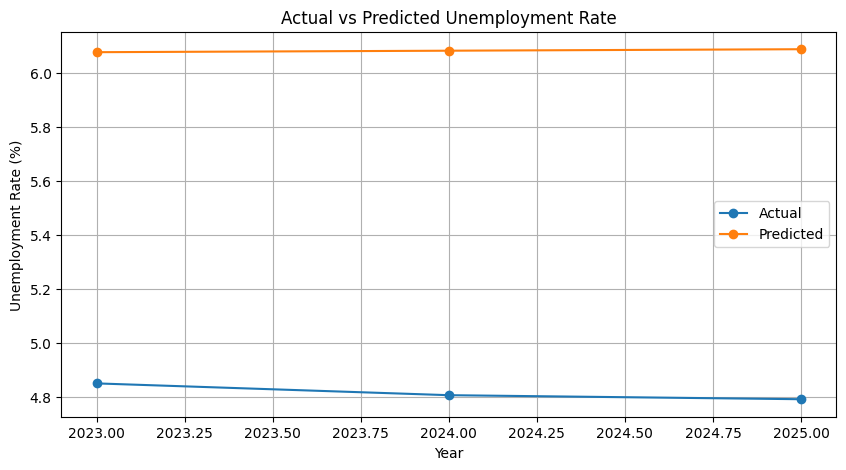

In [21]:
plt.figure(figsize=(10, 5))

plt.plot(
    test["Year"],
    y_test,
    marker="o",
    label="Actual"
)

plt.plot(
    test["Year"],
    y_pred,
    marker="o",
    label="Predicted"
)

plt.title("Actual vs Predicted Unemployment Rate")

plt.xlabel("Year")
plt.ylabel("Unemployment Rate (%)")

plt.legend()
plt.grid(True)

plt.show()

# Predict 2026

In [22]:
future_year = pd.DataFrame({
    "Year": [2026]
})

prediction_2026 = model.predict(future_year)

print(
    "Predicted Global Unemployment Rate for 2026:",
    prediction_2026[0]
)

Predicted Global Unemployment Rate for 2026: 6.092472048121726
